### **[Python for Finance: Analyse Stocks](https://levelup.gitconnected.com/python-for-finance-analyse-stocks-step-by-step-using-python-ed36336057fb)**

1. Load stock price data
2. Clean and prepare the data
3. Calculate daily returns
4. Calculate cumulative returns
5. Add moving averages
6. Measure volatility
7. Calculate maximum drawdown
8. Compare multiple stocks
9. Create useful charts

In [1]:
!pip install -qq pandas numpy matplotlib yfinance seaborn

In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd

import yfinance as yf

import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 4)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.grid'] = False

%autosave 10

Autosaving every 10 seconds


In [3]:
ticker = "AAPL"
data = yf.download(
  ticker,
  start="2023-01-01",
  end="2025-01-01",
  auto_adjust=True,
  progress=False,
  multi_level_index=False
)

display(data.head(10))

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,122.9827,128.7154,122.0977,128.1058,112117500
2023-01-04,124.2512,126.5128,122.9925,124.7723,89113600
2023-01-05,122.9335,125.6377,122.6779,125.0083,80962700
2023-01-06,127.4568,128.1156,122.8057,123.9070,87754700
2023-01-09,127.9779,131.1835,127.7223,128.2926,70790800
2023-01-10,128.5483,129.0694,125.9818,128.0861,63896200
2023-01-11,131.2622,131.2818,128.2828,129.0596,69458900
2023-01-12,131.1835,132.0193,129.2464,131.6457,71379600
2023-01-13,132.5110,132.6684,129.4628,129.8266,57809700


In [4]:
display(data.describe())

,Close,High,Low,Open,Volume
count,502.0000,502.0000,502.0000,502.0000,502.0000
mean,187.8962,189.3871,186.1364,187.6265,58160947.0120
std,28.0621,28.2031,27.8213,28.0565,25123719.2298
min,122.9335,125.6377,122.0977,123.9070,23234700.0000
25%,169.7857,171.4054,168.5382,169.8630,44958000.0000
50%,183.1351,184.4729,181.5203,183.0787,52502850.0000
75%,212.4373,215.1942,210.1372,212.6579,64898075.0000
max,257.3756,258.4488,255.9945,256.5509,318679900.0000


In [5]:
prices = data[["Close"]].copy()
prices.rename(columns={"Close": "close"}, inplace=True)
display(prices.head(10))

,close
Date,
2023-01-03,122.9827
2023-01-04,124.2512
2023-01-05,122.9335
2023-01-06,127.4568
2023-01-09,127.9779
2023-01-10,128.5483
2023-01-11,131.2622
2023-01-12,131.1835
2023-01-13,132.5110


#### **Calculate Daily Returns**

In [6]:
prices["daily_return"] = prices["close"].pct_change()
display(prices.head(10))

,close,daily_return
Date,,
2023-01-03,122.9827,NaN
2023-01-04,124.2512,0.0103
2023-01-05,122.9335,-0.0106
2023-01-06,127.4568,0.0368
2023-01-09,127.9779,0.0041
2023-01-10,128.5483,0.0045
2023-01-11,131.2622,0.0211
2023-01-12,131.1835,-0.0006
2023-01-13,132.5110,0.0101


In [7]:
returns = prices["daily_return"].dropna()

#### **Calculate Cumulative Returns**

In [8]:
prices["cumulative_return"] = (1 + prices["daily_return"]).cumprod() - 1

display(prices[["close", "daily_return", "cumulative_return"]].tail())

,close,daily_return,cumulative_return
Date,,,
2024-12-24,256.5609,0.0115,1.0862
2024-12-26,257.3756,0.0032,1.0928
2024-12-27,253.9674,-0.0132,1.0651
2024-12-30,250.5989,-0.0133,1.0377
2024-12-31,248.8302,-0.0071,1.0233


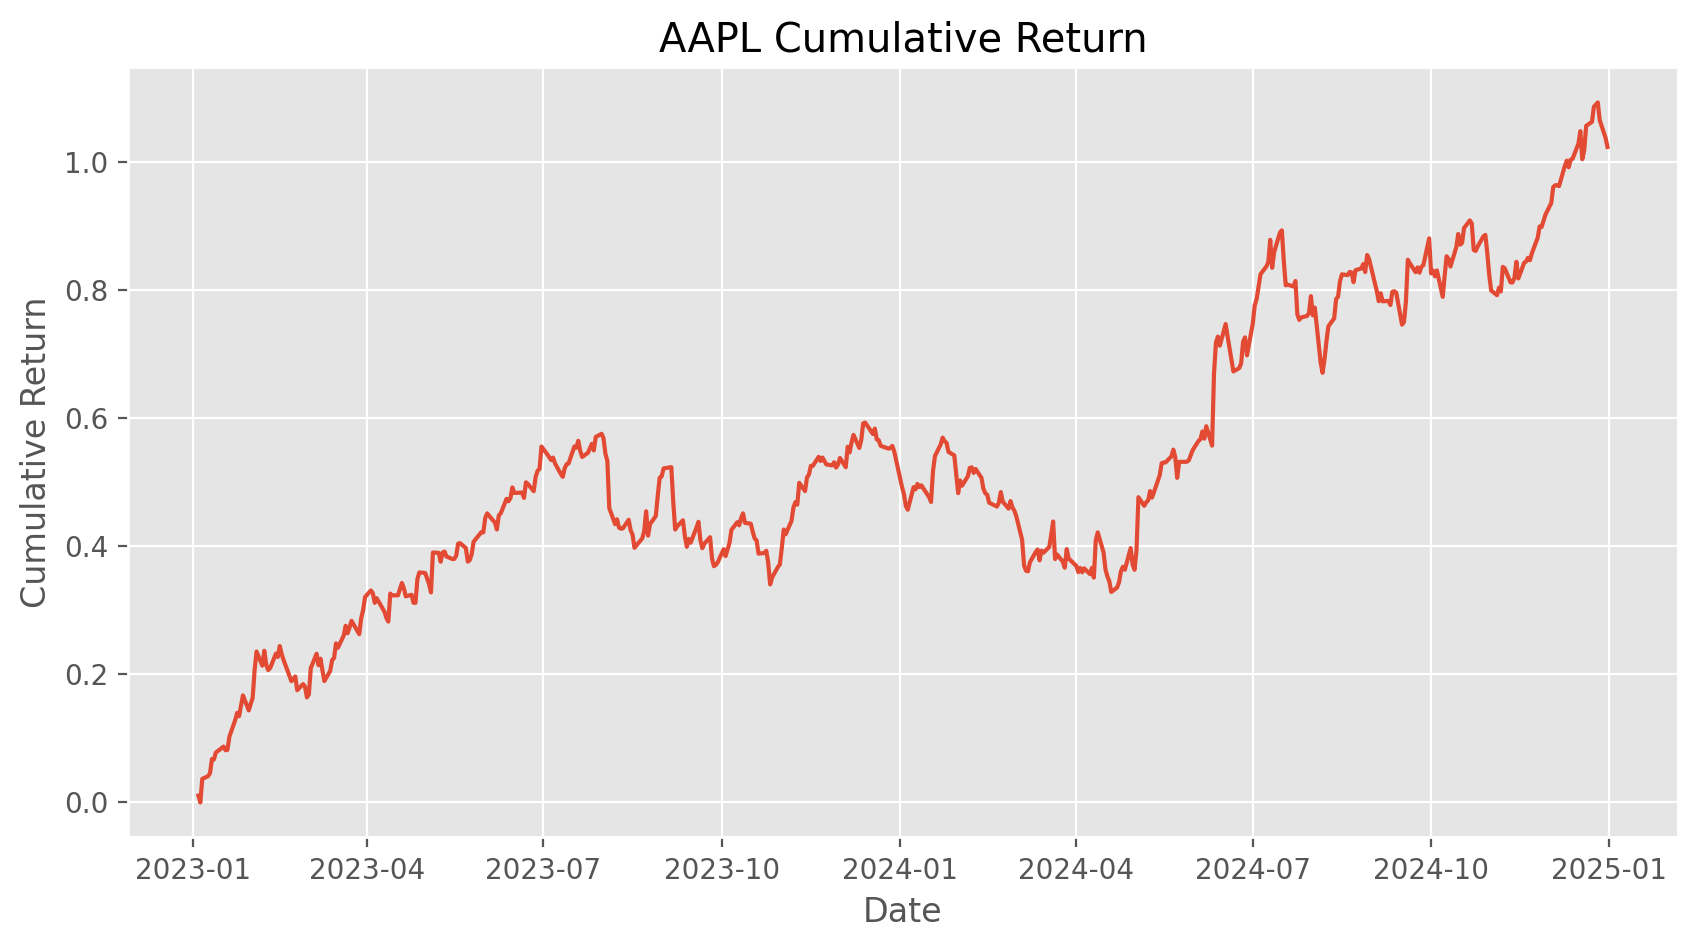

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(prices.index, prices["cumulative_return"])
plt.title(f"{ticker} Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

#### **Add Moving Averages**

In [10]:
prices["ma_20"] = prices["close"].rolling(window=20).mean()
prices["ma_50"] = prices["close"].rolling(window=50).mean()

display(prices[["close", "ma_20", "ma_50"]].tail())

,close,ma_20,ma_50
Date,,,
2024-12-24,256.5609,244.7299,234.3259
2024-12-26,257.3756,245.9203,234.8312
2024-12-27,253.9674,246.9467,235.3094
2024-12-30,250.5989,247.6855,235.7130
2024-12-31,248.8302,248.2236,236.0245


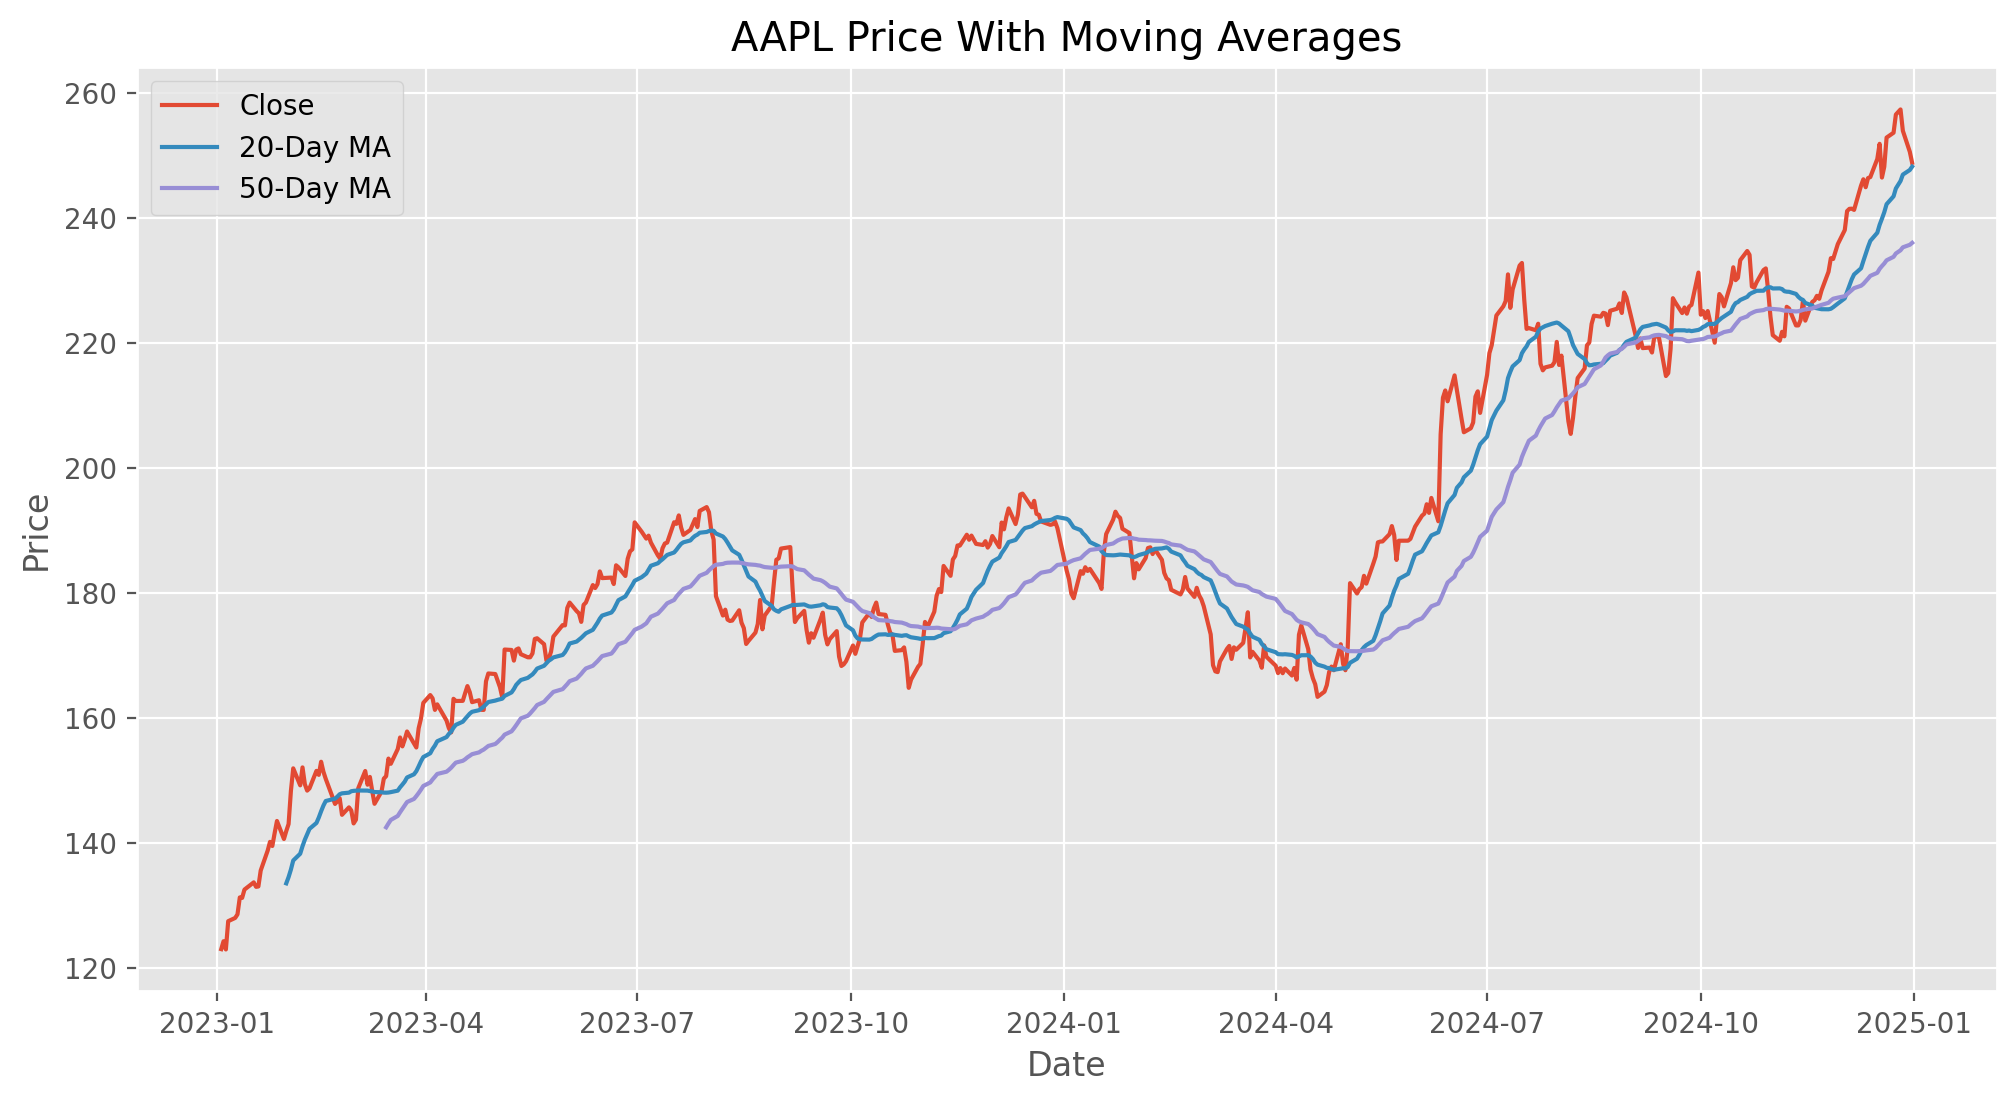

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices["close"], label="Close")
plt.plot(prices.index, prices["ma_20"], label="20-Day MA")
plt.plot(prices.index, prices["ma_50"], label="50-Day MA")
plt.title(f"{ticker} Price With Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

#### **Measure Volatility**

In [12]:
trading_days = 252
prices["rolling_volatility_30d"] = (
  prices["daily_return"]
  .rolling(window=30)
  .std()
  * np.sqrt(trading_days)
)

display(prices[["close", "daily_return", "rolling_volatility_30d"]].tail())

,close,daily_return,rolling_volatility_30d
Date,,,
2024-12-24,256.5609,0.0115,0.1368
2024-12-26,257.3756,0.0032,0.1361
2024-12-27,253.9674,-0.0132,0.1459
2024-12-30,250.5989,-0.0133,0.1515
2024-12-31,248.8302,-0.0071,0.1457


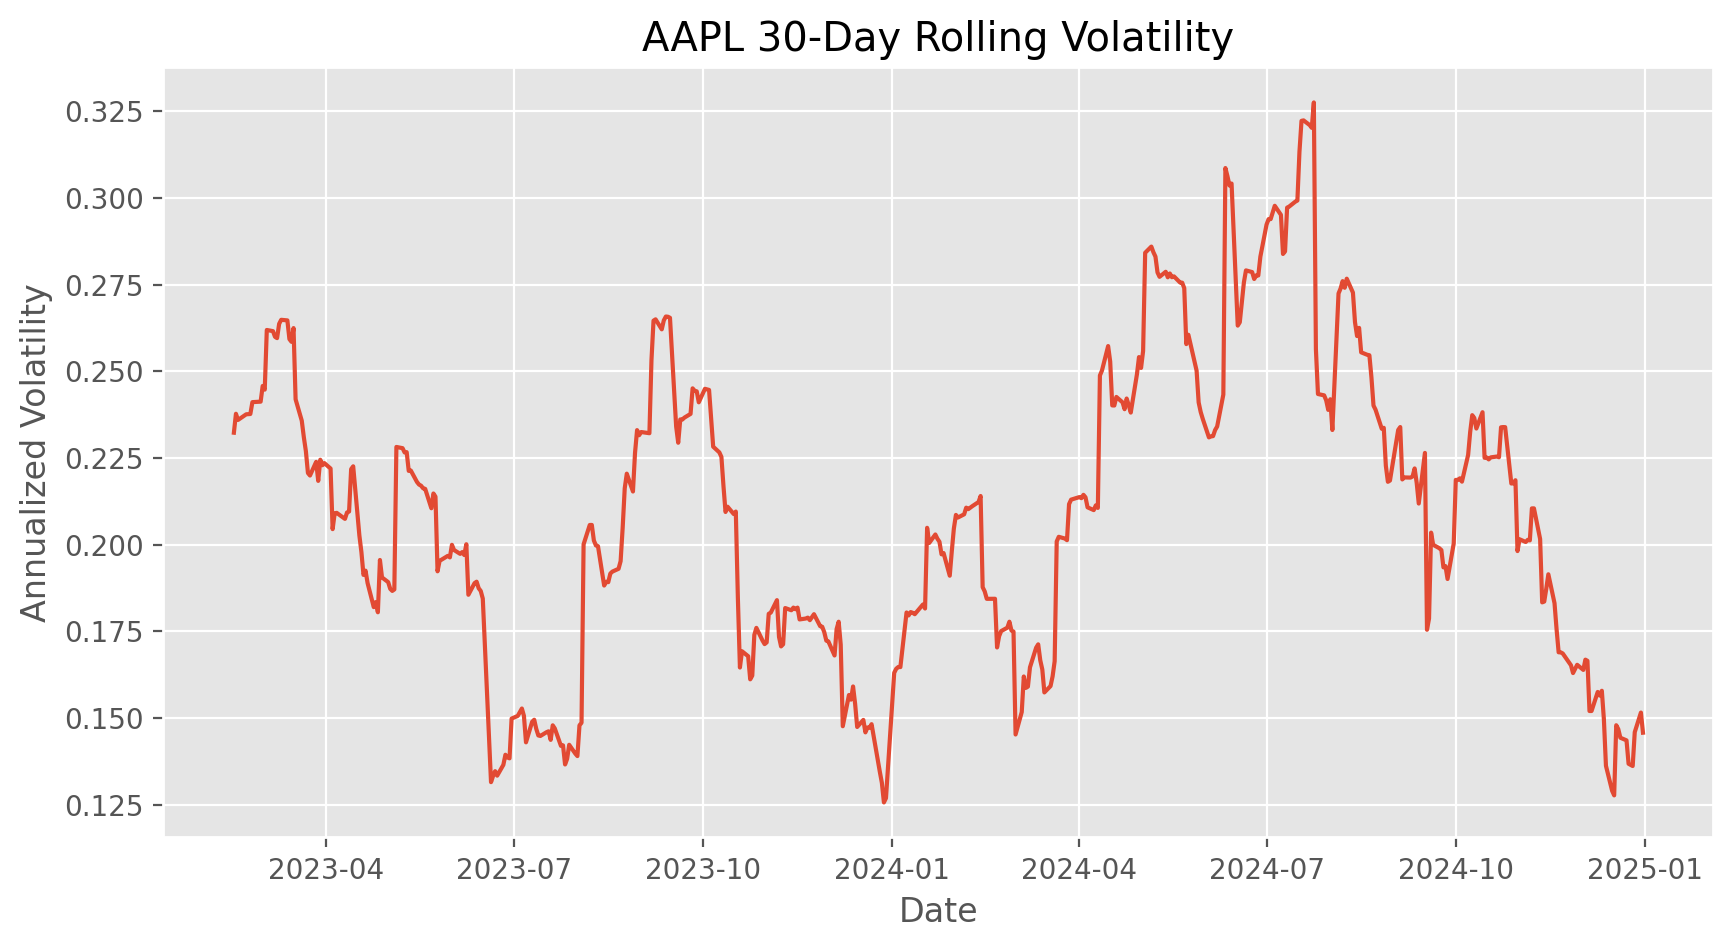

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(prices.index, prices["rolling_volatility_30d"])
plt.title(f"{ticker} 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.grid(True)
plt.show()

#### **Calculate Maximum Drawdown**

In [14]:
prices["running_max"] = prices["close"].cummax()
prices["drawdown"] = prices["close"] / prices["running_max"] - 1

display(prices[["close", "running_max", "drawdown"]].tail())

max_drawdown = prices["drawdown"].min()
print(f"Maximum Drawdown: {max_drawdown:.2%}")

,close,running_max,drawdown
Date,,,
2024-12-24,256.5609,256.5609,0.0000
2024-12-26,257.3756,257.3756,0.0000
2024-12-27,253.9674,257.3756,-0.0132
2024-12-30,250.5989,257.3756,-0.0263
2024-12-31,248.8302,257.3756,-0.0332


Maximum Drawdown: -16.61%


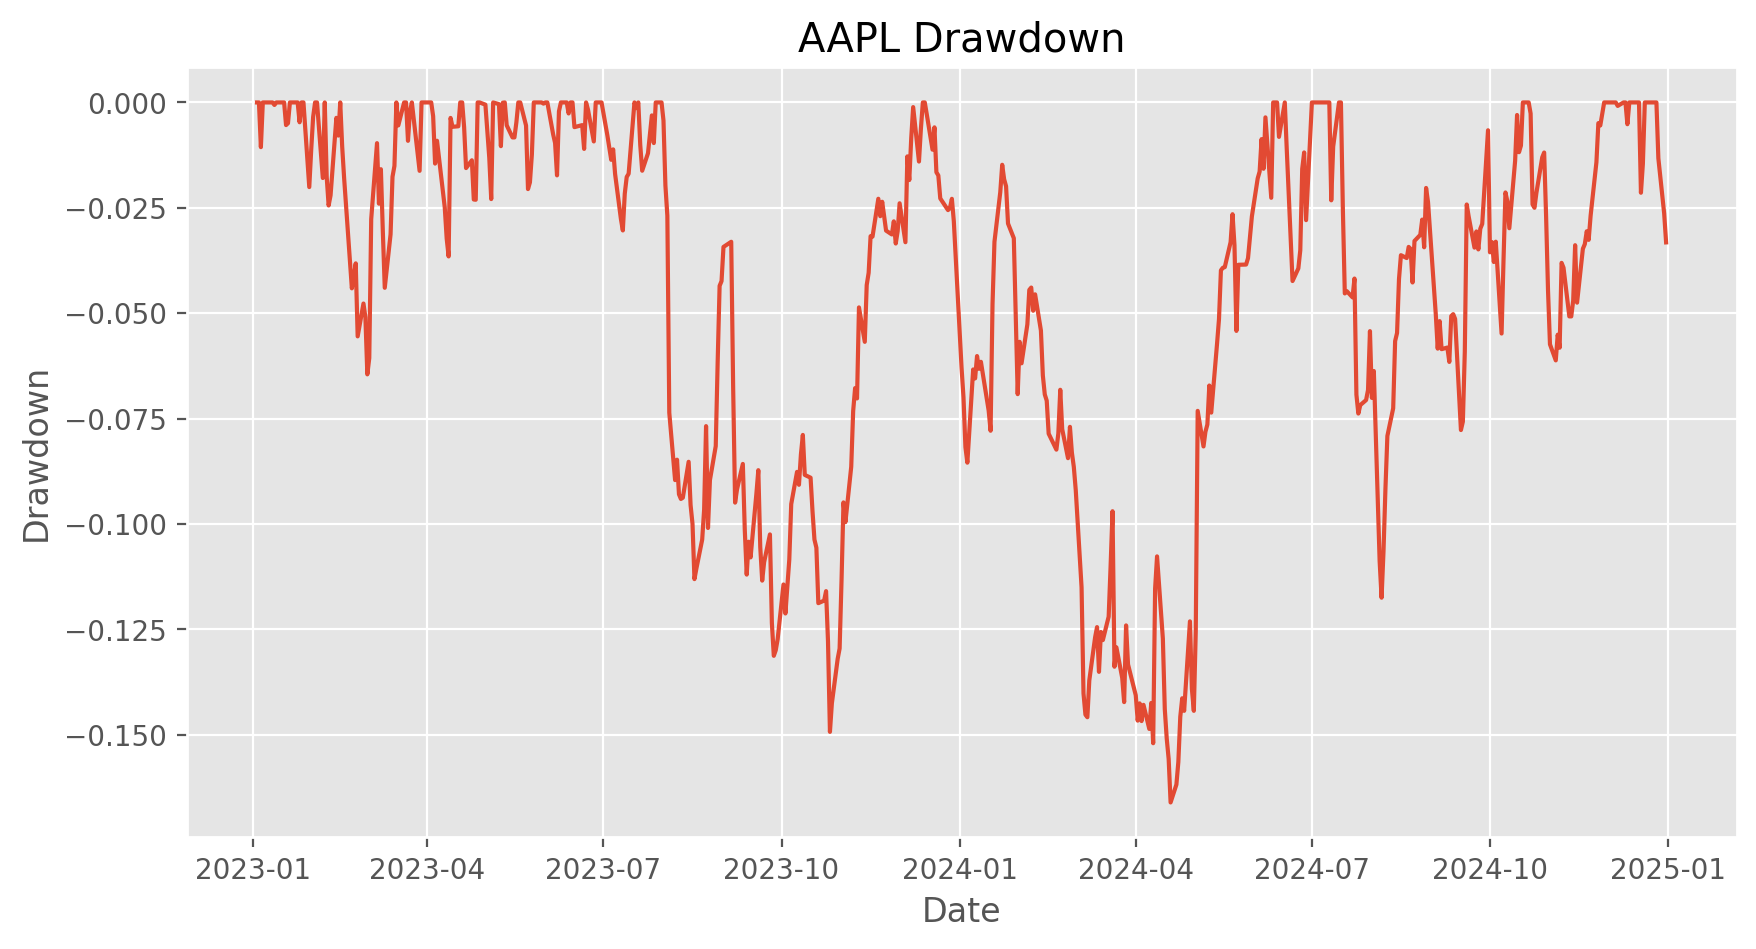

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(prices.index, prices["drawdown"])
plt.title(f"{ticker} Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

#### **Compare Multiple Stocks**

In [16]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL"]
multi_data = yf.download(
  tickers,
  start="2023-01-01",
  end="2025-01-01",
  auto_adjust=True,
  progress=False
)["Close"]
display(multi_data.head())

Ticker,AAPL,GOOGL,MSFT,NVDA
Date,,,,
2023-01-03,122.9827,88.3367,232.9483,14.2833
2023-01-04,124.2512,87.3058,222.7584,14.7163
2023-01-05,122.9335,85.4424,216.1563,14.2334
2023-01-06,127.4568,86.5723,218.7038,14.8261
2023-01-09,127.9779,87.2464,220.8332,15.5934


In [17]:
multi_returns = multi_data.pct_change().dropna()
multi_cumulative = (1 + multi_returns).cumprod() - 1

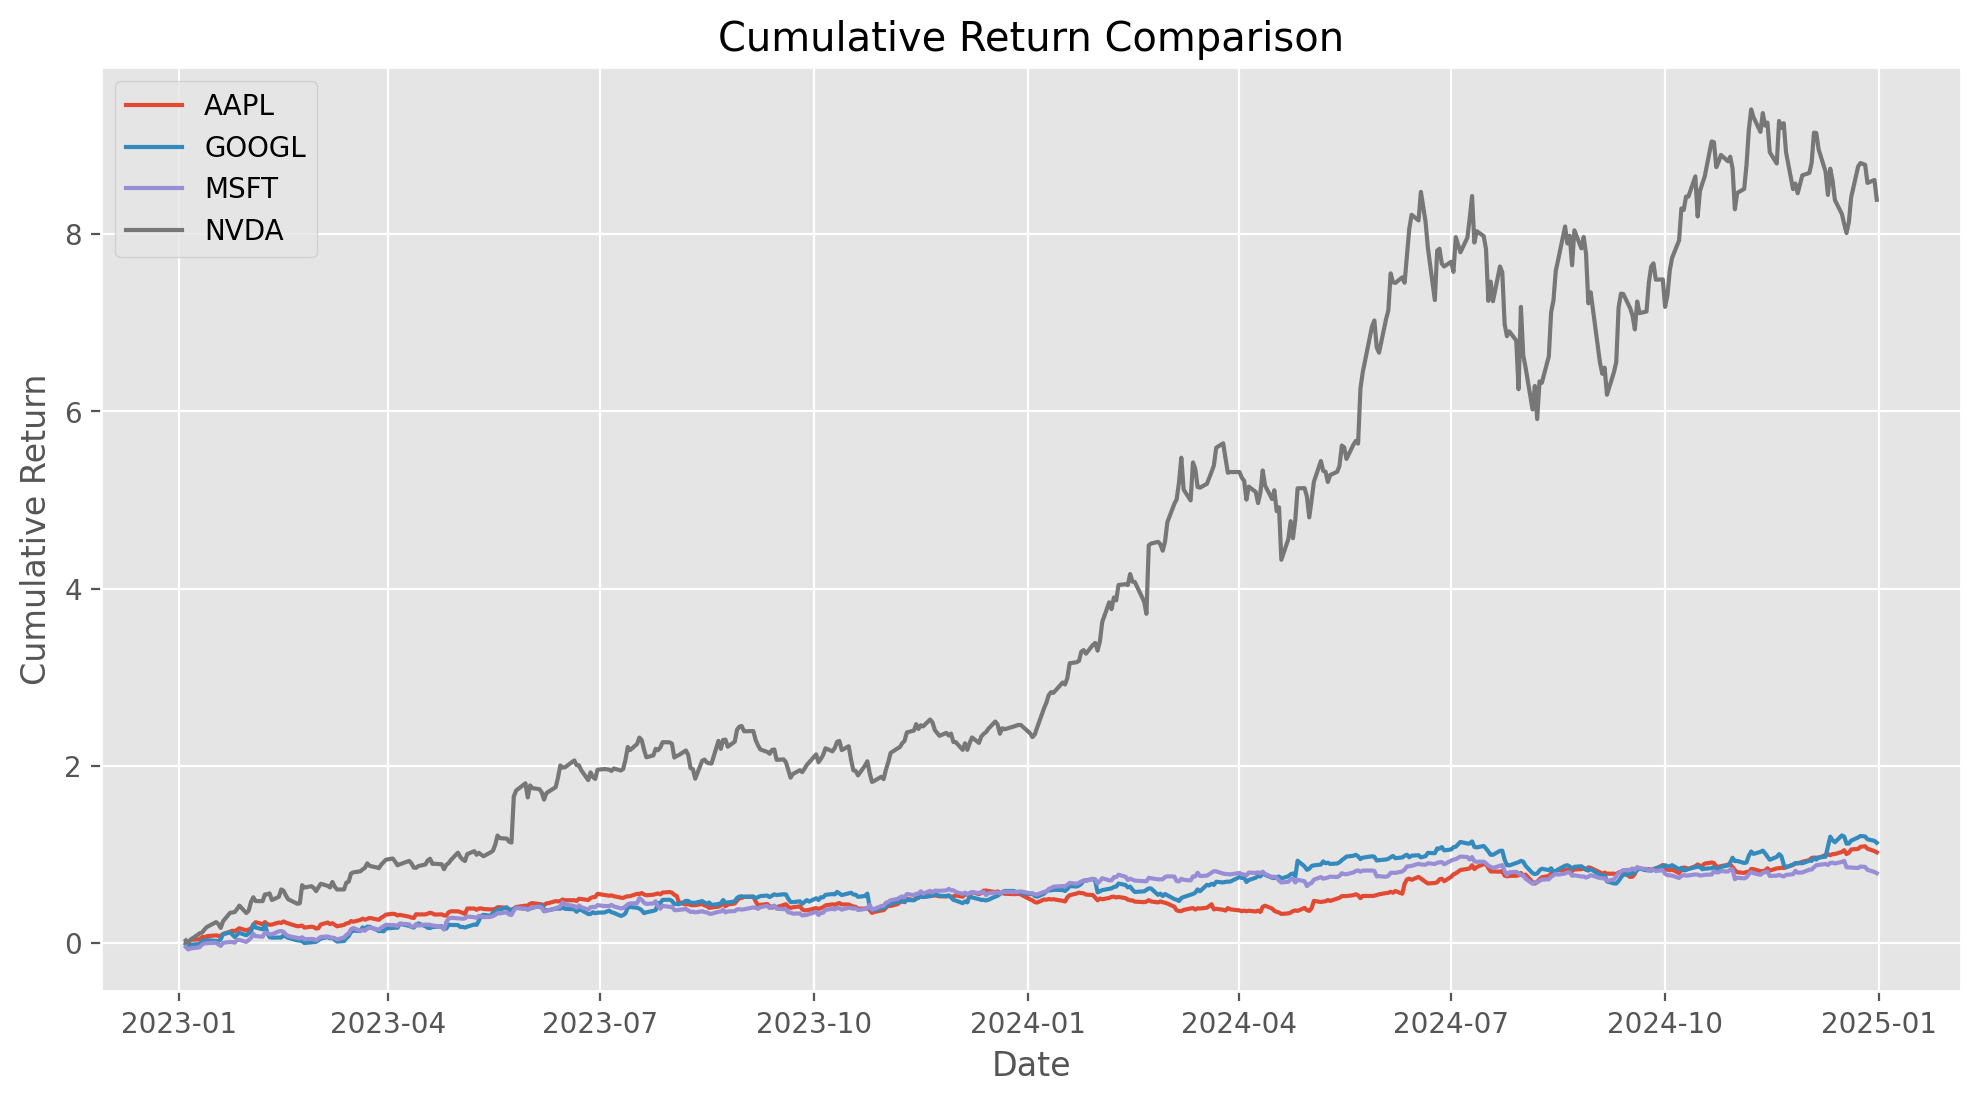

In [18]:
plt.figure(figsize=(12, 6))
for column in multi_cumulative.columns:
  plt.plot(multi_cumulative.index, multi_cumulative[column], label=column)
plt.title("Cumulative Return Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def summarize_stock(price_series: pd.Series) -> dict:
  daily_returns = price_series.pct_change().dropna()
  cumulative_return = (1 + daily_returns).prod() - 1
  annualized_volatility = daily_returns.std() * np.sqrt(252)
  running_max = price_series.cummax()
  drawdown = price_series / running_max - 1
  max_drawdown = drawdown.min()
  return {
    "cumulative_return": cumulative_return,
    "annualized_volatility": annualized_volatility,
    "max_drawdown": max_drawdown,
  }

summary = {}
for ticker in multi_data.columns:
  summary[ticker] = summarize_stock(multi_data[ticker])
summary_df = pd.DataFrame(summary).T
display(summary_df)

,cumulative_return,annualized_volatility,max_drawdown
AAPL,1.0233,0.2135,-0.1661
GOOGL,1.1318,0.2921,-0.2214
MSFT,0.7882,0.2268,-0.1549
NVDA,8.3879,0.5049,-0.2705


In [20]:
formatted_summary = summary_df.applymap(lambda x: f"{x:.2%}")
display(formatted_summary)

,cumulative_return,annualized_volatility,max_drawdown
AAPL,102.33%,21.35%,-16.61%
GOOGL,113.18%,29.21%,-22.14%
MSFT,78.82%,22.68%,-15.49%
NVDA,838.79%,50.49%,-27.05%


In [21]:
def risk_flag(row):
  if row["max_drawdown"] < -0.30 or row["annualized_volatility"] > 0.45:
    return "High Risk"
  elif row["max_drawdown"] < -0.20 or row["annualized_volatility"] > 0.30:
    return "Medium Risk"
  return "Low Risk"

summary_df["risk_flag"] = summary_df.apply(risk_flag, axis=1)
display(summary_df)

,cumulative_return,annualized_volatility,max_drawdown,risk_flag
AAPL,1.0233,0.2135,-0.1661,Low Risk
GOOGL,1.1318,0.2921,-0.2214,Medium Risk
MSFT,0.7882,0.2268,-0.1549,Low Risk
NVDA,8.3879,0.5049,-0.2705,High Risk


In [22]:
if not IN_COLAB:
  summary_df.to_csv("stock_analysis_summary.csv")